# Supervised Learning

## Objective of Supervised Learning

The objective of applying supervised learning in this project is to build a predictive model that can classify customers into predefined categories (such as customer segments) based on their behavioral and demographic features, enabling better decision-making and personalized business strategies.

## Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [3]:
df_cust=pd.read_csv("Churn_Processed.csv")
df=df_cust.copy()

In [4]:
df.head()

,Country,State,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,United States,California,Los Angeles,90003,1,0,0,0,2,1,...,0,0,0,0,0,0,0,0,0,1
1,United States,California,Los Angeles,90005,0,0,0,1,2,1,...,0,0,0,0,0,0,0,0,1,0
2,United States,California,Los Angeles,90006,0,0,0,1,8,1,...,0,0,1,0,1,0,0,0,1,0
3,United States,California,Los Angeles,90010,0,0,1,1,28,1,...,1,0,1,0,1,0,0,0,1,0
4,United States,California,Los Angeles,90015,1,0,0,1,49,1,...,0,0,1,0,1,0,0,0,0,0


In [5]:
df.describe()

,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,0.504756,0.162147,0.483033,0.231010,32.371149,0.903166,0.592219,64.761692,2281.916928,...,0.290217,0.216669,0.384353,0.216669,0.387903,0.209144,0.240664,0.216101,0.335794,0.228880
std,1865.794555,0.500013,0.368612,0.499748,0.421508,24.559481,0.295752,0.491457,30.090047,2265.270398,...,0.453895,0.412004,0.486477,0.412004,0.487307,0.406726,0.427517,0.411613,0.472301,0.420141
min,90001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,92102.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,402.225000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,93552.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,95351.000000,1.000000,0.000000,1.000000,0.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,96161.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 7043 non-null   object 
 1   State                                   7043 non-null   object 
 2   City                                    7043 non-null   object 
 3   Zip Code                                7043 non-null   int64  
 4   Gender                                  7043 non-null   int64  
 5   Senior Citizen                          7043 non-null   int64  
 6   Partner                                 7043 non-null   int64  
 7   Dependents                              7043 non-null   int64  
 8   Tenure Months                           7043 non-null   int64  
 9   Phone Service                           7043 non-null   int64  
 10  Paperless Billing                       7043 non-null   int6

In [7]:
df.isnull().sum()

Country                                   0
State                                     0
City                                      0
Zip Code                                  0
Gender                                    0
Senior Citizen                            0
Partner                                   0
Dependents                                0
Tenure Months                             0
Phone Service                             0
Paperless Billing                         0
Monthly Charges                           0
Total Charges                             0
Churn Label                               0
Churn Value                               0
Churn Score                               0
CLTV                                      0
Churn Reason                              0
Multiple Lines_No phone service           0
Multiple Lines_Yes                        0
Internet Service_Fiber optic              0
Internet Service_No                       0
Online Security_No internet serv

In [8]:
df.duplicated().sum()

np.int64(0)

## Removing Irrelevant Columns

In [9]:
df=df.drop("Churn Label",axis=1)
df=df.drop("Country",axis=1)
df=df.drop("State",axis=1)
df=df.drop("Zip Code",axis=1)
df=df.drop("Churn Reason",axis=1)
df=df.drop("CLTV",axis=1)
df=df.drop("Churn Score",axis=1)
df=df.drop("City",axis=1)

In [10]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Paperless Billing', 'Monthly Charges',
       'Total Charges', 'Churn Value', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

In [11]:
df.dtypes

Gender                                      int64
Senior Citizen                              int64
Partner                                     int64
Dependents                                  int64
Tenure Months                               int64
Phone Service                               int64
Paperless Billing                           int64
Monthly Charges                           float64
Total Charges                             float64
Churn Value                                 int64
Multiple Lines_No phone service             int64
Multiple Lines_Yes                          int64
Internet Service_Fiber optic                int64
Internet Service_No                         int64
Online Security_No internet service         int64
Online Security_Yes                         int64
Online Backup_No internet service           int64
Online Backup_Yes                           int64
Device Protection_No internet service       int64
Device Protection_Yes                       int64


## Logistic Regression

In [12]:
X=df.drop("Churn Value",axis=1)
y=df["Churn Value"]

In [13]:
X.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Multiple Lines_No phone service,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,2,1,1,53.85,108.15,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,1,2,1,1,70.70,151.65,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,8,1,1,99.65,820.50,0,...,0,0,1,0,1,0,0,0,1,0
3,0,0,1,1,28,1,1,104.80,3046.05,0,...,1,0,1,0,1,0,0,0,1,0
4,1,0,0,1,49,1,1,103.70,5036.30,0,...,0,0,1,0,1,0,0,0,0,0


In [14]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Churn Value, dtype: int64

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,test_size=0.3,stratify=y
)

In [16]:
print(y_train[y_train==1])
print(y_train[y_train==0])

596     1
1836    1
228     1
1608    1
1592    1
       ..
417     1
1753    1
99      1
1413    1
872     1
Name: Churn Value, Length: 1308, dtype: int64
5963    0
3535    0
4689    0
3447    0
4190    0
       ..
5006    0
2964    0
6507    0
3870    0
6017    0
Name: Churn Value, Length: 3622, dtype: int64


In [17]:
model=LogisticRegression(max_iter=10000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [18]:
y_pred=model.predict(X_test)

In [19]:
print("Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred)*100,"%")
print("F1 Score",f1_score(y_test,y_pred)*100,"%")
print("Recall",recall_score(y_test,y_pred)*100,"%")

Accuracy: 81.06956933270232 %
Precision: 65.81532416502947 %
F1 Score 62.616822429906534 %
Recall 59.71479500891266 %


In [20]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [21]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [22]:
y_pred=model.predict(X_test)

In [23]:
print("Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred)*100,"%")
print("F1 Score",f1_score(y_test,y_pred)*100,"%")
print("Recall",recall_score(y_test,y_pred)*100,"%")

Accuracy: 80.97491717936583 %
Precision: 65.6188605108055 %
F1 Score 62.42990654205608 %
Recall 59.53654188948306 %


In [61]:
accuracy_lr=accuracy_score(y_test,y_pred)*100
precision_lr=precision_score(y_test,y_pred)*100
f1_lr=f1_score(y_test,y_pred)*100
recall_lr=recall_score(y_test,y_pred)*100

## Decision Tree

In [51]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [52]:
model=DecisionTreeClassifier()

In [53]:
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
y_pred_test=model.predict(X_test)
y_pred_train=model.predict(X_train)

In [55]:
print("Training Accuracy:",accuracy_score(y_train,y_pred_train))
print("Testing Accuracy:",accuracy_score(y_test,y_pred_test))
print("Precision:",precision_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

Training Accuracy: 0.9979716024340771
Testing Accuracy: 0.7198296261239944
Precision: 0.5007923930269413
F1 Score: 0.5184577522559475
Recall: 0.5374149659863946


### Note:
This is a Classic Case Of Overfitting

In [57]:
model=DecisionTreeClassifier(
    max_depth=3
)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

Accuracy: 0.7875059157595835
Precision: 0.7026239067055393
F1 Score: 0.5177228786251342
Recall: 0.4098639455782313


In [62]:
model=DecisionTreeClassifier(
    max_depth=5
)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

accuracy_dt=accuracy_score(y_test,y_pred)*100
precision_dt=precision_score(y_test,y_pred)*100
f1_dt=f1_score(y_test,y_pred)*100
recall_dt=recall_score(y_test,y_pred)*100

Accuracy: 0.7898722195929957
Precision: 0.6192052980132451
F1 Score: 0.62751677852349
Recall: 0.6360544217687075


In [59]:
model=DecisionTreeClassifier(
    max_depth=7
)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

Accuracy: 0.7775674396592522
Precision: 0.616600790513834
F1 Score: 0.5703839122486288
Recall: 0.5306122448979592


The max_depth parameter was tuned,and it was observed that the F1-Score was highest at depth=5. Increasing the depth beyond this point resulted in decreased performance due to overfitting.Therefore,max_depth=5 was selected as the optimal value.

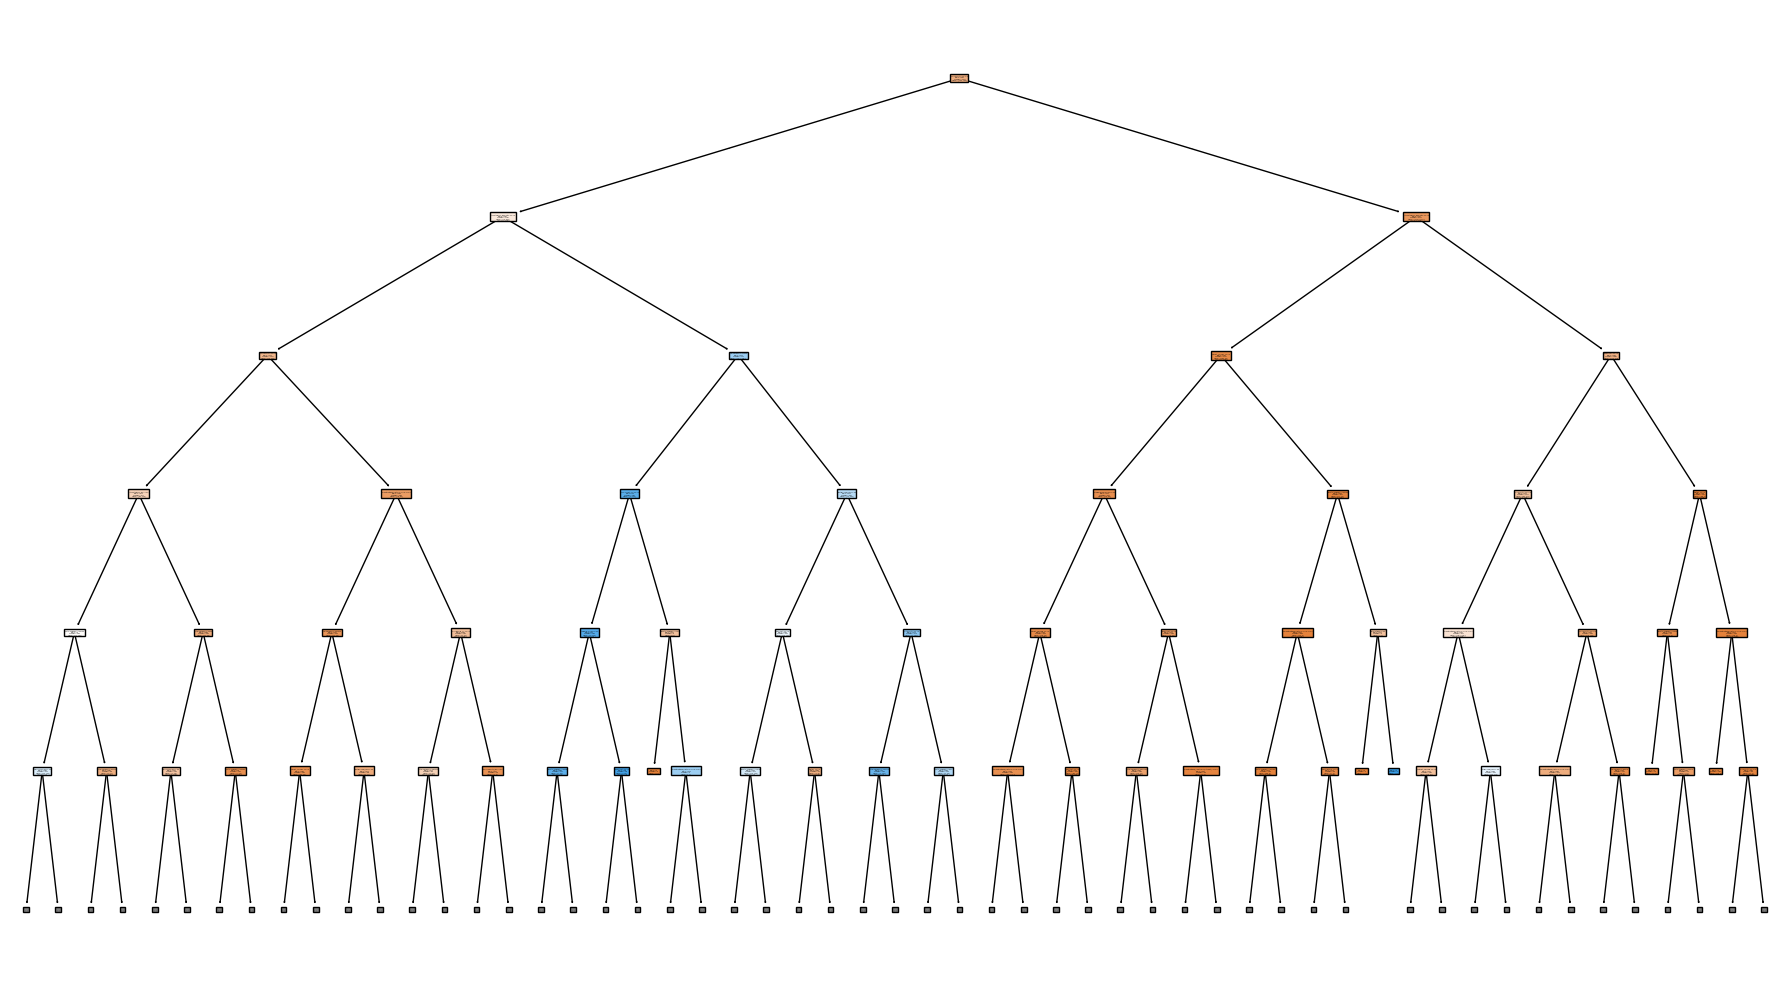

In [60]:
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Churn","Churn"],
    filled=True,
    max_depth=5
)
plt.tight_layout()

## Random Forest

In [42]:
rf=RandomForestClassifier(
    max_depth=3,
    oob_score=True
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB Score:",rf.oob_score_*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

OOB Score: 78.55983772819472 %
Testing Accuracy: 78.37198296261239 %
Precision: 0.7630522088353414
f1 score: 0.4540023894862604
Recall: 0.3231292517006803


In [43]:
rf=RandomForestClassifier(
    max_depth=5,
    oob_score=True
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB Score:",rf.oob_score_*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

OOB Score: 79.67545638945234 %
Testing Accuracy: 79.5551348793185 %
Precision: 0.703125
f1 score: 0.5555555555555556
Recall: 0.45918367346938777


In [44]:
rf=RandomForestClassifier(
    max_depth=7,
    oob_score=True
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB Score:",rf.oob_score_*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

OOB Score: 80.22312373225152 %
Testing Accuracy: 80.26502602934217 %
Precision: 0.6930022573363431
f1 score: 0.5955383123181377
Recall: 0.5221088435374149


In [45]:
rf=RandomForestClassifier(
    max_depth=9,
    oob_score=True
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB Score:",rf.oob_score_*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

OOB Score: 80.38539553752535 %
Testing Accuracy: 81.11689540937056 %
Precision: 0.6981132075471698
f1 score: 0.6253521126760564
Recall: 0.5663265306122449


In [46]:
rf=RandomForestClassifier(
    max_depth=11,
    oob_score=True
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB Score:",rf.oob_score_*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

OOB Score: 80.10141987829614 %
Testing Accuracy: 80.69096071935637 %
Precision: 0.6867219917012448
f1 score: 0.6186915887850467
Recall: 0.5629251700680272


The max_depth parameter was tuned to control the complexity of the random forest model.
It was observed that the model performance(in terms of accuracy and F1-Score) improved with increasing depth up to 9,after which it started decreasing ,indicating overfitting. Hence,max_depth was set to 9 as the optimal value

In [72]:
rf=RandomForestClassifier(
    n_estimators=50,
    max_depth=9,
    oob_score=True
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB Score:",rf.oob_score_*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

accuracy_rf=accuracy_score(y_test,y_pred)*100
precision_rf=precision_score(y_test,y_pred)*100
f1_rf=f1_score(y_test,y_pred)*100
recall_rf=recall_score(y_test,y_pred)*100

OOB Score: 80.32454361054768 %
Testing Accuracy: 80.50165641268339 %
Precision: 0.6841004184100419
f1 score: 0.6135084427767354
Recall: 0.5561224489795918


In [48]:
rf=RandomForestClassifier(
    n_estimators=100,
    max_depth=9,
    oob_score=True
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB Score:",rf.oob_score_*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

OOB Score: 80.30425963488844 %
Testing Accuracy: 80.69096071935637 %
Precision: 0.6882845188284519
f1 score: 0.6172607879924953
Recall: 0.5595238095238095


In [49]:
rf=RandomForestClassifier(
    n_estimators=150,
    max_depth=9,
    oob_score=True
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB Score:",rf.oob_score_*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

OOB Score: 80.85192697768763 %
Testing Accuracy: 80.64363464268813 %
Precision: 0.693304535637149
f1 score: 0.6108468125594672
Recall: 0.5459183673469388


It was observed that the F1 Score remained constant for n_estimators=50,100 and 150,indicating that increasing the number of trees did not significantly imporoved model performance.Therefore,n_estimators=50 was selected as the optimal value to ensure computational efficiency without compromising accuracy

## Support Vector Machine

In [34]:
svc=SVC()

In [35]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [36]:
svc.fit(X_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [37]:
y_pred=svc.predict(X_test_scaled)

In [38]:
print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("f1 Score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

Accuracy score: 0.8135352579271179
Precision: 0.709051724137931
f1 Score: 0.6254752851711026
Recall: 0.5595238095238095


In [64]:
# Linear Kernel

svc=SVC(kernel="linear")
svc.fit(X_train_scaled,y_train)

y_pred=svc.predict(X_test_scaled)

print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("f1 Score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

accuracy_svc=accuracy_score(y_test,y_pred)*100
precision_svc=precision_score(y_test,y_pred)*100
f1_svc=f1_score(y_test,y_pred)*100
recall_svc=recall_score(y_test,y_pred)*100

Accuracy score: 0.8102224325603408
Precision: 0.6888888888888889
f1 Score: 0.6297322253000923
Recall: 0.5799319727891157


In [40]:
# Polynomial Kernel

svc=SVC(kernel="poly")
svc.fit(X_train_scaled,y_train)

y_pred=svc.predict(X_test_scaled)

print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("f1 Score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

Accuracy score: 0.8069096071935636
Precision: 0.7284263959390863
f1 Score: 0.5845213849287169
Recall: 0.4880952380952381


In [41]:
# Sigmoid Kernel

svc=SVC(kernel="sigmoid")
svc.fit(X_train_scaled,y_train)

y_pred=svc.predict(X_test_scaled)

print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("f1 Score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

Accuracy score: 0.7382867960246096
Precision: 0.5332068311195446
f1 Score: 0.5040358744394619
Recall: 0.477891156462585


Since Both Linear and RBF kernels showed similar performance in terms of accuracy and F1-Score.The linear kernel was selected due to its simplicity,lower computational cost, and better interpretability.

## Comparing All Models

In [66]:
data={
    'Model':['Logistic Regression','Decision Tree','Random Forest','SVC'],
    'Accuracy':[accuracy_lr,accuracy_dt,accuracy_rf,accuracy_svc],
    'Precision':[precision_lr,precision_dt,precision_rf,precision_svc],
    'F1 Score':[f1_lr,f1_dt,f1_rf,f1_svc],
    'Recall':[recall_lr,recall_dt,recall_rf,recall_svc]
}

comparison_table=pd.DataFrame(data)
comparison_table

,Model,Accuracy,Precision,F1 Score,Recall
0,Logistic Regression,77.756744,61.660079,57.038391,53.061224
1,Decision Tree,78.987222,61.920530,62.751678,63.605442
2,Random Forest,80.501656,68.565401,61.205273,55.272109
3,SVC,81.022243,68.888889,62.973223,57.993197


In [67]:
comparison_table.sort_values(by='F1 Score',ascending=False)

,Model,Accuracy,Precision,F1 Score,Recall
3,SVC,81.022243,68.888889,62.973223,57.993197
1,Decision Tree,78.987222,61.920530,62.751678,63.605442
2,Random Forest,80.501656,68.565401,61.205273,55.272109
0,Logistic Regression,77.756744,61.660079,57.038391,53.061224


Among all the models,Support Vector Machine(SVC) achieved the highest F1-Score, indicating the best balance between Precision and Recall.
Therefore, SVM was selected as the final Model for Customer Churn Prediction.

## Confusion Matrix

In [68]:
# Linear Kernel

svc=SVC(kernel="linear")
svc.fit(X_train_scaled,y_train)

y_pred=svc.predict(X_test_scaled)

print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("f1 Score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

accuracy_svc=accuracy_score(y_test,y_pred)*100
precision_svc=precision_score(y_test,y_pred)*100
f1_svc=f1_score(y_test,y_pred)*100
recall_svc=recall_score(y_test,y_pred)*100

Accuracy score: 0.8102224325603408
Precision: 0.6888888888888889
f1 Score: 0.6297322253000923
Recall: 0.5799319727891157


In [71]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[1371  154]
 [ 247  341]]


The model performs well in identifying non-churn customers, but some churn cases are missed, as indicated by false negatives. Reducing false negatives is important to improve customer retention stratergies.

## Feature Importance

Although Support Vector Machine(SVM) achieved highest F1-Score and was selected as the final predictive model, Random Forest was also used to analyze feature importance. Random Forest provides insights into which features contribute most to the customer churn, which is not easily obtainable from SVM.This helps in deriving meaningful business insights and improve decision-making.

In [73]:
rf=RandomForestClassifier(
    n_estimators=50,
    max_depth=9,
    oob_score=True
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB Score:",rf.oob_score_*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("Precision:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

accuracy_rf=accuracy_score(y_test,y_pred)*100
precision_rf=precision_score(y_test,y_pred)*100
f1_rf=f1_score(y_test,y_pred)*100
recall_rf=recall_score(y_test,y_pred)*100

OOB Score: 80.38539553752535 %
Testing Accuracy: 80.73828679602461 %
Precision: 0.6865979381443299
f1 score: 0.6206896551724138
Recall: 0.5663265306122449


In [76]:
imp=model.feature_importances_

feature_imp=pd.DataFrame({
    'Feature':X.columns,
    'Importance':imp
})

feature_imp=feature_imp.sort_values(
    by='Importance',
    ascending=False
)

feature_imp

,Feature,Importance
4,Tenure Months,0.437155
11,Internet Service_Fiber optic,0.314769
3,Dependents,0.081899
8,Total Charges,0.042377
28,Payment Method_Electronic check,0.031378
12,Internet Service_No,0.028648
7,Monthly Charges,0.018655
10,Multiple Lines_Yes,0.014987
26,Contract_Two year,0.010220
20,Tech Support_Yes,0.005604


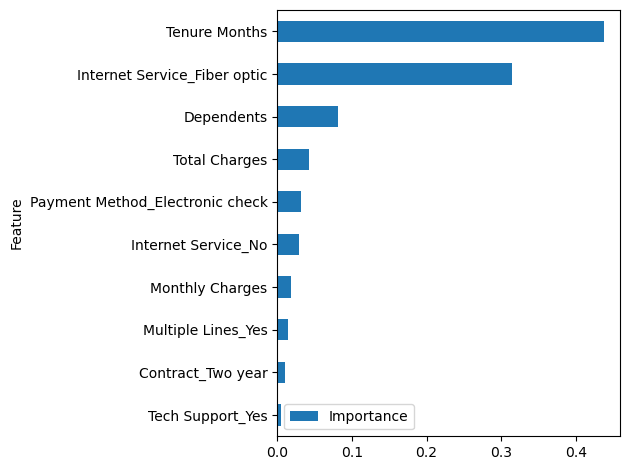

In [83]:
feature_imp.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Business Insights

### Tenure Months

Observation: Customers with fewer tenure months are more likely to churn.  
Insight: New customers are at higher risk of leaving; early engagement and onboarding are critical.  
Business Action: Offer welcome programs, tutorials, or early discounts to retain new customers.

## Internet Service_Fiber Optic
Observation: Customers using Fiber Optic internet churn more compared to others.  
Insight: Fiber optic users may have higher expectations or face service issues, leading to churn.  
Business Action: Improve service quality, offer support, or loyalty programs for Fiber users.

## Dependents
Observation: Customers with dependents are less likely to churn.  
Insight: Customers with families may value stability and long-term service, reducing churn risk.  
Business Action: Tailor family-oriented plans or bundles to retain these customers.

## Total Charges
Observation: Higher total charges correlate with higher churn.  
Insight: Price sensitivity exists — customers paying more are more likely to leave.  
Business Action: Introduce flexible pricing, discounts, or loyalty benefits for high-paying customers.

## Payment Method_Electronic Check
Observation: Customers using electronic check as a payment method churn more often.  
Insight: Certain payment methods may be inconvenient or associated with dissatisfaction.  
Business Action: Encourage automatic payments or more convenient payment options to reduce churn

## Conclusion

“Feature importance analysis using Random Forest revealed that tenure, type of internet service, dependents, total charges, and payment method significantly affect customer churn. New customers, Fiber optic users, and those paying by electronic check are more likely to churn, whereas customers with dependents tend to stay. Total charges also influence churn, indicating price sensitivity. These insights can guide targeted retention strategies such as improved onboarding, family-oriented plans, and flexible payment options.”